In [1]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows
import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats

In [2]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [3]:
uvh5name[4*275]

'/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.49903.sum.uvh5'

In [4]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  

antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))
freqs = uvd1.freq_array[np.where((uvd1.freq_array>50e6) & (uvd1.freq_array<75e6))]*1e-6

#make redundant groups model        
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)

In [5]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Low_gleam_model_final.uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)


antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [6]:
N=250
def extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, N=N):
    cal_all_data=[]
    for i in range(N):
  
        cal_data = np.load(file_name+uvh5name[4*(i+2)][40:69]+"_low.npy", allow_pickle=True).item()
        # print(i)
        # print(cal_data)
        cal_all_data.append(cal_data) 
    return cal_all_data        

In [7]:

# filter_name="Notch_filter_40_mHz"
filter_name="Main_lobe_20_mHz"

In [8]:
# cal_data_full=extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, N=N)

In [9]:
cal_data_notch_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_Notch_filter_40_mHz_gleam_", uvh5name=uvh5name, N=N)

In [10]:
cal_data_main_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_", uvh5name=uvh5name, N=N)

In [11]:
cal_data_gleam=extrac_cal_data(file_name=path_data+"abs_calibrated_data_gleam_", uvh5name=uvh5name, N=N)

In [12]:
hd_gleam_model = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Low_gleam_model_final.uvh5")
hd_gleam_model.read()
data_diffuse,_,_=hd_gleam_model.build_datacontainers()

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.
antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [13]:
bls=reds[0]
model_bls=[]
for bl in bls:
    bls_yy=(bl[0],bl[1],'yy')
    if bls_yy in data_diffuse:
        model_bls.append(bls_yy)

def plot_redundant_abs(start=0, N=10, freqs=freqs, cal_data="", title_name=""):
    for n in range (N):
        i=n+start
        for bls in cal_data[i]:

            plt.semilogy(freqs[50:-1],np.abs(cal_data[i][bls][0][50:-1]))
    plt.title(title_name)
    plt.xlabel("Freq [MHz]")
    plt.ylabel("|V|[Jy]")        

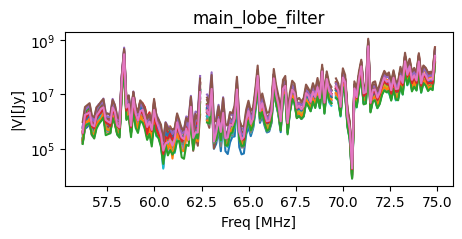

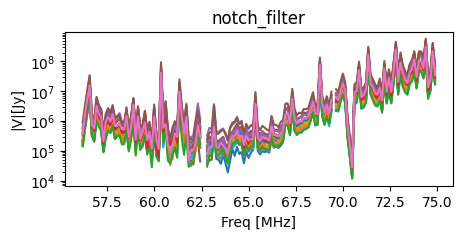

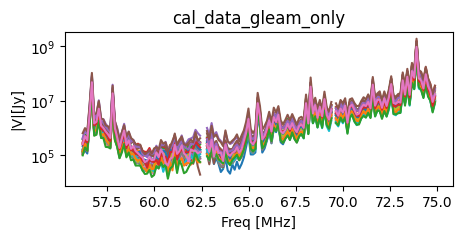

In [14]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_data_main_filter, title_name="main_lobe_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_data_notch_filter, title_name="notch_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam_only")


In [15]:
def vis_perform_delay_trans2(freqs=freqs, data=cal_data_gleam):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
   
    data_full_bls=[]
    for bls in data:
        data_time_no_nans=data[bls][0,:][~np.isnan(data[bls][0,:])]
        freq_no_nans=freqs[~np.isnan(data[bls][0,:])]
        coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        data_fitted=[]
        for i in range (data[bls][0,:].shape[0]):
            if np.isnan(data[bls][0,:][i]):
                data_fitted.append(poly(x_fit[i]))
            else:
                data_fitted.append(data[bls][0,:][i])
        data_fitted=np.array(data_fitted) 
       
        data_full_bls.append(data_fitted)
        
    data_full_bls=np.array(data_full_bls)
    
    # data_full_fitted=np.array(data_full_fitted)
    cross_power=[]
    for i in range (data_full_bls.shape[0]):
        for k in range (data_full_bls.shape[0]):
            if k>i:
                g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))[index]
                g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[k]))[index]
                cross_power.append(g0_delay*np.conjugate(g1_delay))
                
    cross_power=np.array(cross_power)
    return data_full_bls, cross_power, tau_pos

In [16]:
def vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
    cross_power=[]
    for t in range(len(data)):
        data_full_bls=[]
        for bls in data[t]:
            data_time_no_nans=data[t][bls][0,:][~np.isnan(data[t][bls][0,:])]
            freq_no_nans=freqs[~np.isnan(data[t][bls][0,:])]
            coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
            poly = np.poly1d(coeffs)
            x_fit=freqs
            y_fit=poly(x_fit)
            data_fitted=[]
            for i in range (data[t][bls][0,:].shape[0]):
                if np.isnan(data[t][bls][0,:][i]):
                    data_fitted.append(poly(x_fit[i]))
                else:
                    data_fitted.append(data[t][bls][0,:][i])
            data_fitted=np.array(data_fitted) 
           
            data_full_bls.append(data_fitted)
            
        data_full_bls=np.array(data_full_bls)
        
        # data_full_fitted=np.array(data_full_fitted)
        for i in range (data_full_bls.shape[0]):
            # for k in range (130):
            #     if k>i:
                   
                    g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))[index]
                    # g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[k]))[index]
                    # cross_power.append(g0_delay*np.conjugate(g1_delay))
                    cross_power.append(np.abs(g0_delay))
                
    cross_power=np.array(cross_power)
    return data_full_bls, cross_power, tau_pos

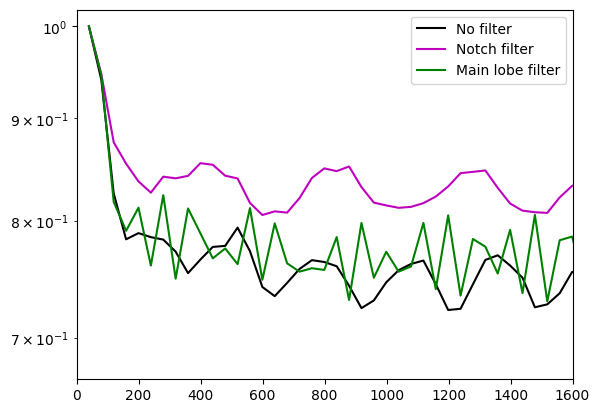

In [17]:
# n=0
# c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_LST[n])
# c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_LST[n])
# c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_LST[n])


# n=0
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam)
c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_notch_filter)
c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_main_filter)
p_ave= np.mean(p, axis=0)
p_ave2= np.mean(p2, axis=0)
p_ave3= np.mean(p3, axis=0)
plt.semilogy(tau, np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="No filter")
plt.semilogy(tau, np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="Notch filter")
plt.semilogy(tau, np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe filter")
# for i in range (100):
#     plt.plot(tau, np.abs(p[i,:]),'k')
#     plt.plot(tau, np.abs(p2[i,:]),'g')
#     plt.plot(tau, np.abs(p3[i,:]),'m')
plt.xlim([0,1600])
plt.legend()

(0.0, 2000.0)

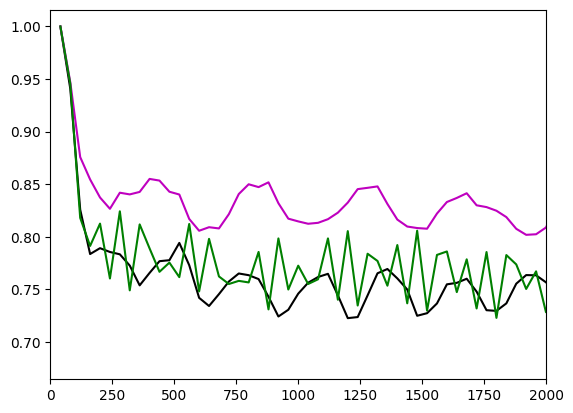

In [19]:
# p_ave= np.mean(p, axis=0)
# p_ave2= np.mean(p2, axis=0)
# p_ave3= np.mean(p3, axis=0)
plt.plot(tau, np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="No filter")
plt.plot(tau, np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="Notch filter")
plt.plot(tau, np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe filter")
# plt.plot(tau, np.abs(p[0,:]),'k')
plt.xlim([0,2000])


(0.0, 2000.0)

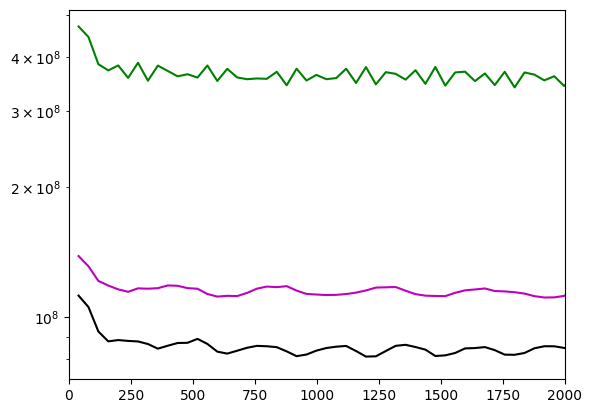

In [21]:
# p_ave= np.mean(p, axis=0)
# p_ave2= np.mean(p2, axis=0)
# p_ave3= np.mean(p3, axis=0)
plt.semilogy(tau, np.abs(p_ave),'k', label="No filter")
plt.semilogy(tau, np.abs(p_ave2),'m', label="Notch filter")
plt.semilogy(tau, np.abs(p_ave3),'g', label="Main lobe filter")
# plt.plot(tau, np.abs(p[0,:]),'k')
plt.xlim([0,2000])

In [179]:
# for key in cal_data_gleam[0].keys():
#     plt.semilogy(freqs,  np.abs(cal_data_gleam[0][key][0,:]))
# plt.semilogy(freqs,np.abs(cross_all_time)[0,:],'k')

## Gain analysis

In [180]:
N=250
def extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for i in range (N):
        g1=np.load(path_data+gain_name+uvh5name[4*(i+2)][43:69]+"_low.npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                gain_temp.append(g1[ant][t,:])
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)
    gains_gleam=np.array(gains_gleam) 

    return gains_gleam
    
gains_gleam_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
# gains_full=extract_antenna_averaged_gains(gain_name="gains/gains_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_Notch_filter_40_mHz_gleam_flagged_abscal", N=N,uvh5name=uvh5name)

def flag_rfi(gains, f_0, f_1, freqs):
    index_flag=np.where((freqs>=f_0 ) & (freqs<=f_1))
    for t in range (gains.shape[0]):
        gains[t,:][index_flag]=np.ones(gains[t,:][index_flag].shape)*np.nan
    # print(gains[index_flag])
    return gains


flag_low=69.85
flag_high=71.20
gains_gleam=flag_rfi(gains=gains_gleam_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_gleam_filter=flag_rfi(gains=gains_gleam_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full_filter=flag_rfi(gains=gains_full_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)    

In [181]:


def extract_antenna_gains_all_times(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for i in range (N):
        g1=np.load(path_data+gain_name+uvh5name[i]+".npy",allow_pickle=True).item()
        
        for ant in g1:
            gain_temp=[]
            for t in range (2):
                gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gains_gleam.append(np.mean(gain_temp,axis=0))
    gains_gleam=np.array(gains_gleam) 

    return gains_gleam    

def produce_plots_every_n_time(n=10, N=N, gains=gains_gleam):
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    plt.figure(figsize=(5,2))
                plt.plot(freqs[50:-1],gains[i,:][50:-1])
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")

def produce_plots_colour_every_n_time(n=10, N=N, gains=gains_gleam):
    cl_al=[c['color'] for c in plt.rcParams['axes.prop_cycle']]
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    #plt.figure(figsize=(5,2))
                    cl=cl_al[m]
                plt.plot(freqs[50:-1],gains[i,:][50:-1], cl)
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")                
        
def produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam, lsts=lsts):
    for m in range (int(N/n)):
        gain_temp=[]
        for i in range (N):
            
            if n*m<=i and i<(m+1)*n:
                
                if i==m*n:
                    gain_temp.append(gains[i,:][50:-1])
        gain_temp=np.array(gain_temp)
        gains_ave=np.mean(gain_temp, axis=0)
                
        plt.plot(freqs[50:-1],gains_ave, label="lst ="+str(np.round(lsts[m*n],2)))    
        plt.xlabel("Freqs [MHz]")
        plt.ylabel("|g|")
        plt.legend()

# Extract gains

# Subset of freqs

Text(0, 0.5, '|g|')

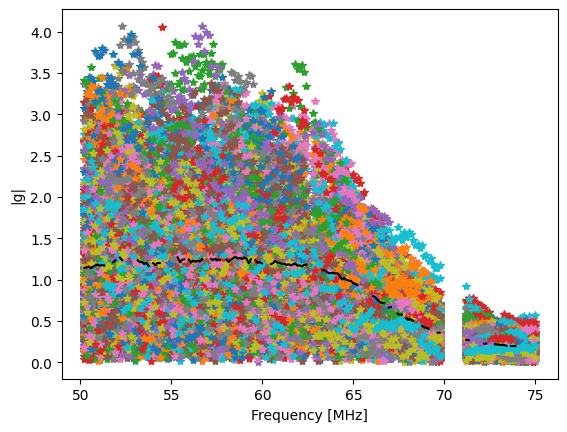

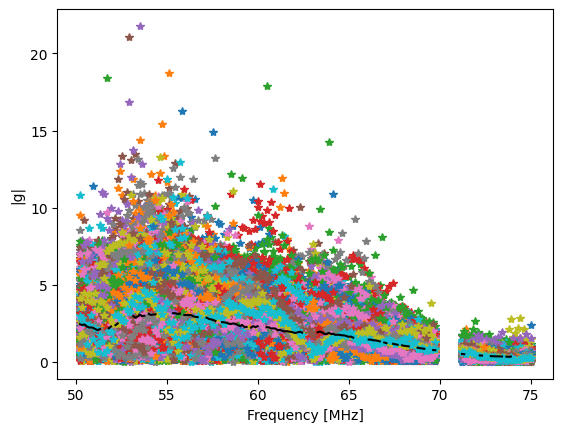

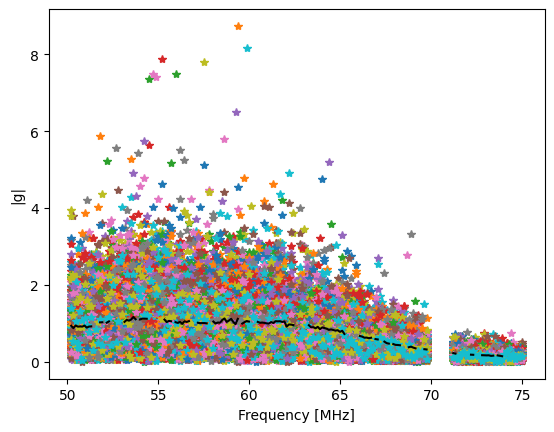

In [202]:

for i in range (gains_gleam.shape[0]):
    plt.plot(freqs,np.abs(gains_gleam[i,:]),'*')

plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")

plt.figure()
for i in range (gains_full_filter.shape[0]):
    plt.plot(freqs,np.abs(gains_full_filter[i,:]),'*')

plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter), axis=0)),'k')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")

plt.figure()

for i in range (gains_gleam.shape[0]):
    plt.plot(freqs,np.abs(gains_gleam_filter[i,:]),'*')

plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter), axis=0)),'k')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")


In [183]:
def fit_gains_and_perform_delay_trans_at_each_time(freqs=freqs[50:-1], gains_raw=gains_gleam[:,50:-1]):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e9
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    gains_delay_all=[]
    for i in range(gains.shape[0]):
        
        gains_delay_all.append(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i,:][index])
    g0_delay=np.mean(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted))),axis=0)[index]
    
    return np.array(gains_delay_all), tau_pos



Text(0, 0.5, '|g|')

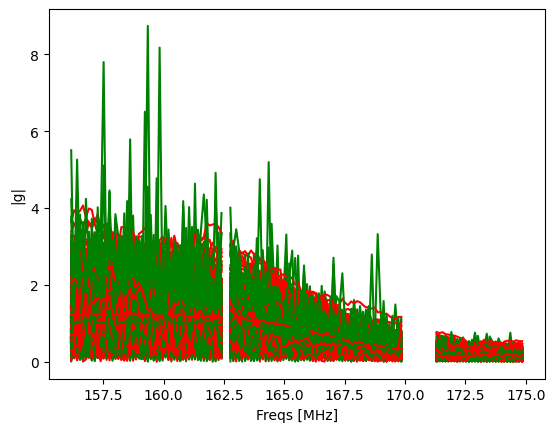

In [146]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[50:-1],np.abs(gains_gleam_filter[i,50:-1]), 'g')
    plt.plot(freqs[50:-1],np.abs(gains_gleam[i,50:-1]), 'r')

plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam_filter[:,50:-1]), axis=0)),'g')  
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam[:,50:-1]), axis=0)),'r')  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

## Avarage gain amplitude

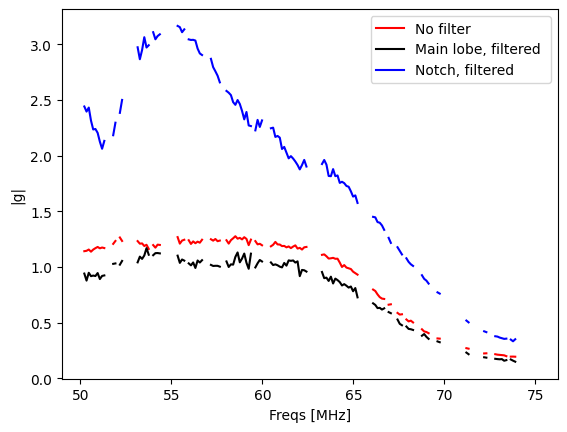

In [184]:
# plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_full[:,50:-1]), axis=0)),'g', label="full sky model") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'r', label="No filter") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter), axis=0)),'k', label="Main lobe, filtered ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter), axis=0)),'b', label="Notch, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

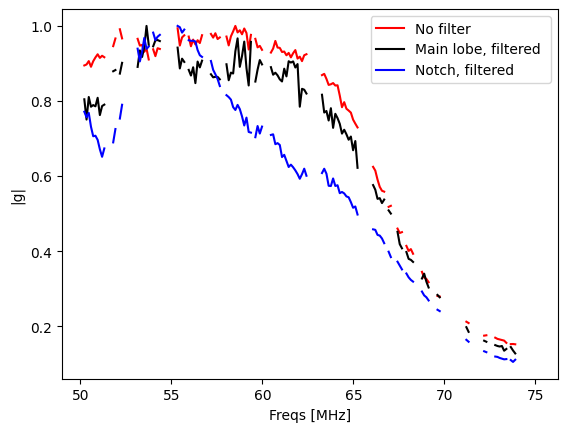

In [185]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam), axis=0))),'r', label="No filter") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam_filter), axis=0))),'k', label="Main lobe, filtered ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_full_filter), axis=0))),'b', label="Notch, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

In [186]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[:,50:-1]):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e9
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    g0_delay=np.mean(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted))),axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted, g0_delay, tau_pos

In [187]:
def fit_gains_and_perform_average_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[:,50:-1]):
    gains=np.mean(np.abs(gains_raw), axis=0)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e9
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
    gains_time_no_nans=gains[~np.isnan(gains)]
    freq_no_nans=freqs[~np.isnan(gains)]
    coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
    poly = np.poly1d(coeffs)
    x_fit=freqs
    y_fit=poly(x_fit)
    gains_fitted=poly(x_fit)
    g0_delay=np.fft.fftshift(np.abs(np.fft.fft(window*gains_fitted)))[index]
    
    return gains_fitted, gains, g0_delay, tau_pos

In [190]:
def produce_plots_delay_ave(n,N):
    #gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[n:N,50:-1])
    gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_average_delay_trans(freqs=freqs, gains_raw=gains_gleam[n:N,:])
    gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_average_delay_trans(freqs=freqs, gains_raw=gains_gleam_filter[n:N,:])
    gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_average_delay_trans(freqs=freqs, gains_raw=gains_full_filter[n:N,:])
    
    #plt.plot(freqs[50:-1], gains_full_ave,'k', label="full")
    plt.plot(freqs, gains_gleam_ave, 'r', label="gleam")
    plt.plot(freqs, gains_gleam_filter_ave, 'g', label="gleam filter")
    plt.plot(freqs, gains_full_filter_ave, 'm', label="full filter")
    plt.xlabel("Freq[MHz]")
    plt.legend()
    plt.figure()
    # print(tau_pos, gleam_delay)
    #plt.semilogy(tau_pos, full_delay,'k')
    # plt.semilogy(tau_pos, gleam_delay,'r')
    # plt.semilogy(tau_pos, gleam_filter_delay,'g')
    #plt.semilogy(tau_pos, full_filter_delay,'m')

    # plt.semilogy(tau_pos, full_delay/np.max(full_delay),'k')
    plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'r')
    plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    
    plt.xlim([0,500])

In [191]:
# produce_plots_delay_ave(n=10,N=220)

## Delay Transform average gain

In [197]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[:,50:-1]):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    gains_delay_all=[]
    for i in range(gains.shape[0]):
        
        gains_delay_all.append(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i,:][index])
    g0_delay=np.mean(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted))),axis=0)[index]
    
    return np.array(gains_delay_all), np.mean(gains_full_fitted, axis=0), gains_full_fitted, g0_delay, tau_pos





In [205]:
def produce_plots_delay(n,N):
    #gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[n:N,50:-1])
    gains_delay_all1, gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs, gains_raw=gains_gleam[n:N,:])
    gains_delay_all2, gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs, gains_raw=gains_gleam_filter[n:N,:])
    gains_delay_all3, gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs, gains_raw=gains_full_filter[n:N,:])
    
    #plt.plot(freqs[50:-1], gains_full_ave,'k', label="full")
    plt.plot(freqs, gains_gleam_ave/np.max(gains_gleam_ave), 'r', label="No filter")
    plt.plot(freqs, gains_gleam_filter_ave/np.max(gains_gleam_filter_ave), 'g', label="Main lobe filter")
    plt.plot(freqs, gains_full_filter_ave/np.max(gains_full_filter_ave), 'm', label="Notch filter")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("|g|")
    plt.legend()
    # plt.figure()
    # for i in range(gains_delay_all1.shape[0]):
    #     plt.semilogy(tau_pos, gains_delay_all1[i,:]/np.max(gains_delay_all1[i,:]),'r--')
        
    # plt.xlim([0,500])    
    # plt.figure()
    
      
    # for i in range(gains_delay_all1.shape[0]):
    #     plt.semilogy(tau_pos, gains_delay_all2[i,:]/np.max(gains_delay_all2[i,:]),'g--')
    # plt.xlim([0,500])
    # plt.figure()  
      
    # for i in range(gains_delay_all1.shape[0]):   
    #     plt.semilogy(tau_pos, gains_delay_all3[i,:]/np.max(gains_delay_all3[i,:]),'m--')
        
    # print(tau_pos, gleam_delay)
    #plt.semilogy(tau_pos, full_delay,'k')
    # plt.semilogy(tau_pos, gleam_delay,'r')
    # plt.semilogy(tau_pos, gleam_filter_delay,'g')
    #plt.semilogy(tau_pos, full_filter_delay,'m')
    plt.figure()
    # # plt.semilogy(tau_pos, full_delay/np.max(full_delay),'k')
    plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'r')
    plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    plt.xlabel("Delay $\\tau [ns]$")
    plt.ylabel("$|g(\\tau)|$")
    plt.xlim([0,1500])

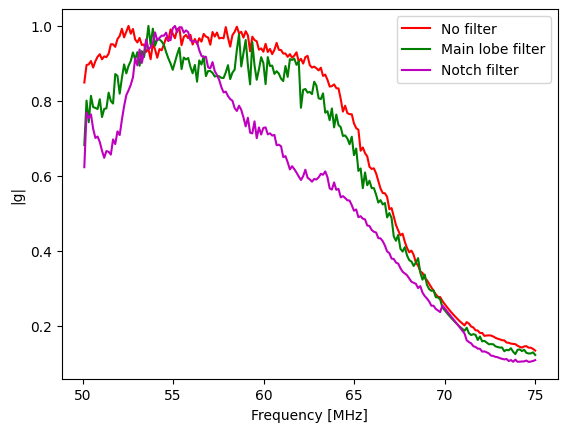

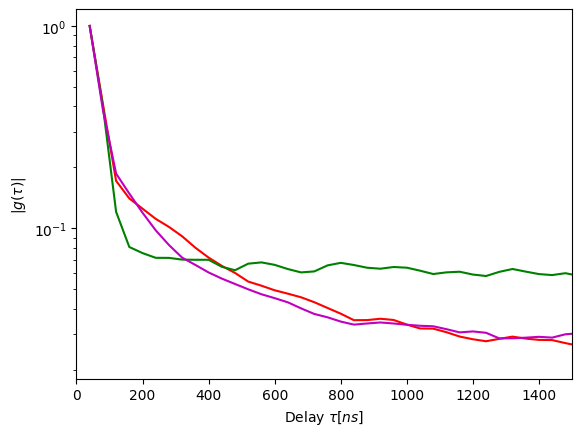

In [206]:
produce_plots_delay(n=10,N=250)

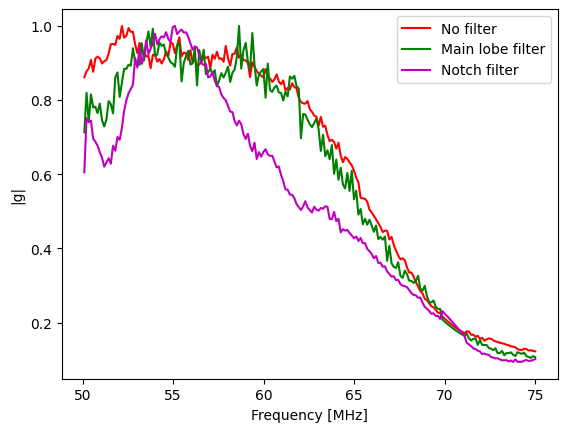

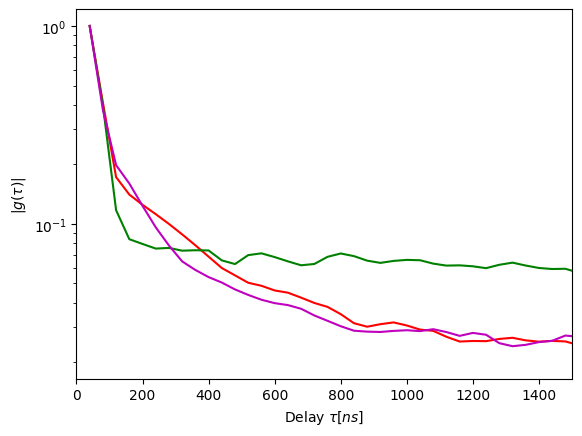

In [207]:
produce_plots_delay(n=100,N=250)

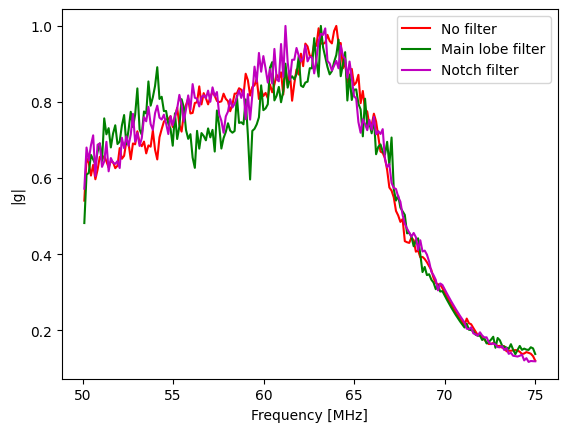

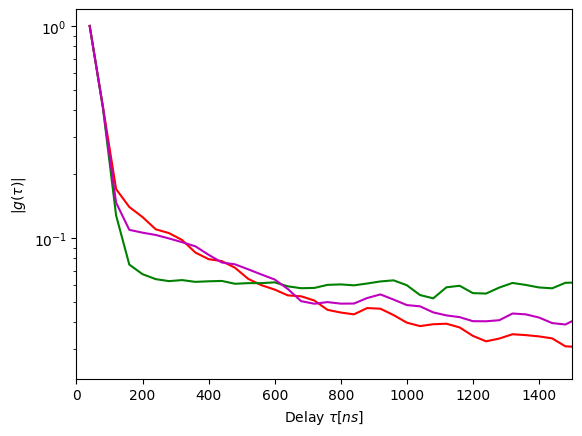

In [208]:
produce_plots_delay(n=10,N=100)

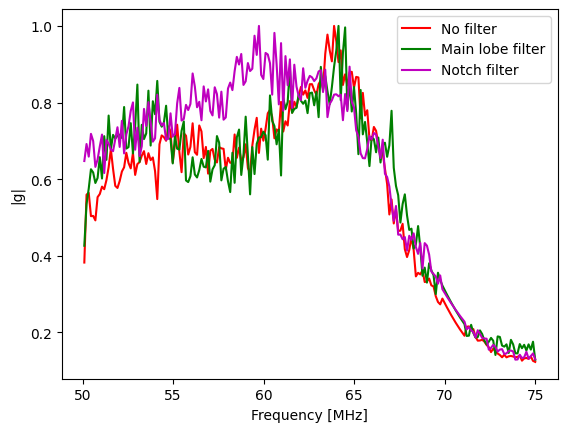

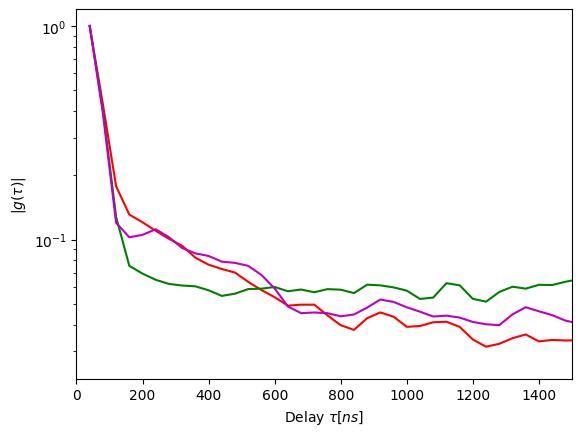

In [209]:
produce_plots_delay(n=10,N=50)

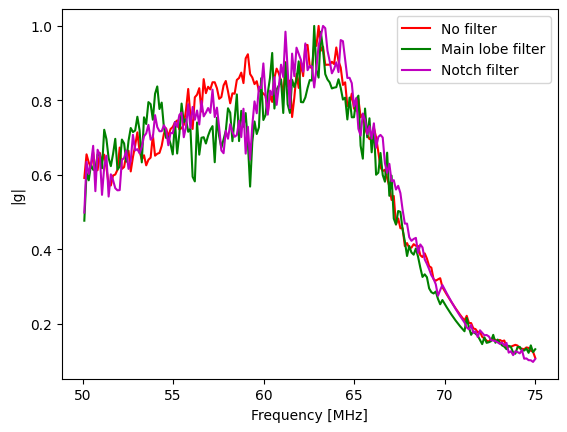

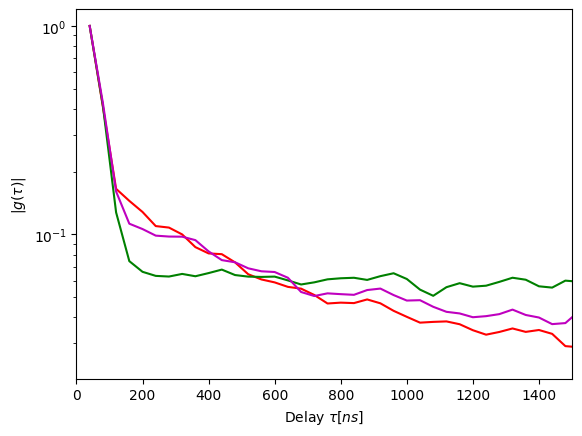

In [210]:
produce_plots_delay(n=50,N=100)

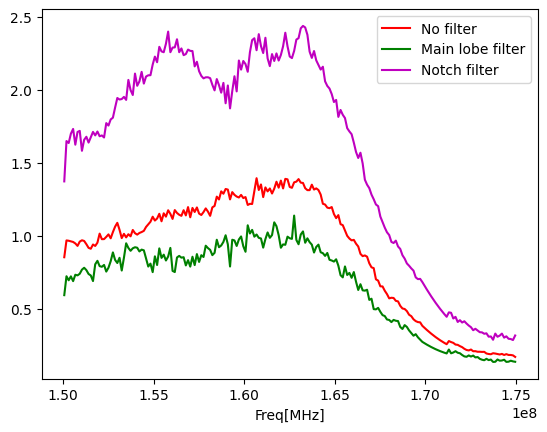

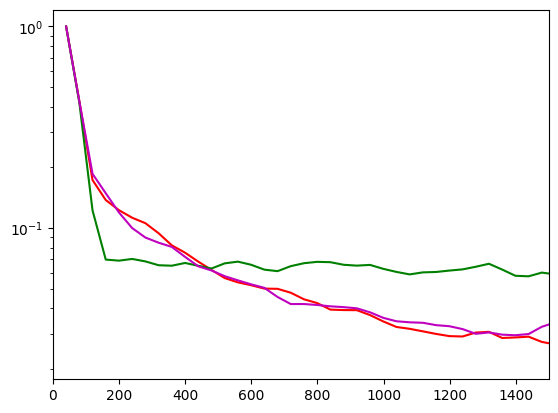

In [246]:
produce_plots_delay(n=50,N=150)

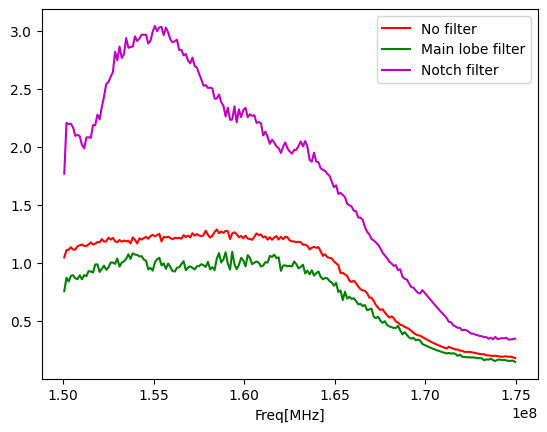

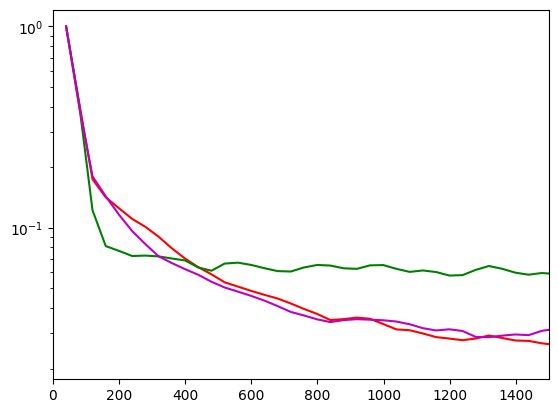

In [249]:
produce_plots_delay(n=0,N=220)

In [102]:
lsts[0]

np.float64(2.6037717617299694)

In [103]:
lsts[100]

np.float64(2.8729421415141045)

In [60]:
40*60*100.0

240000.0

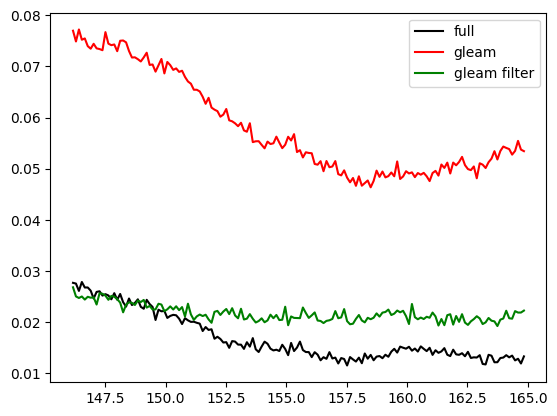

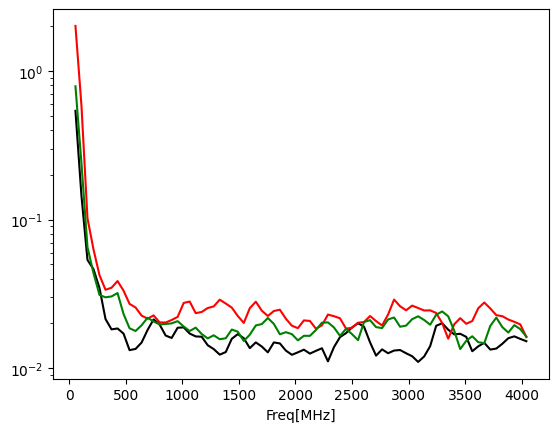

In [59]:
produce_plots_delay(n=50,N=70)

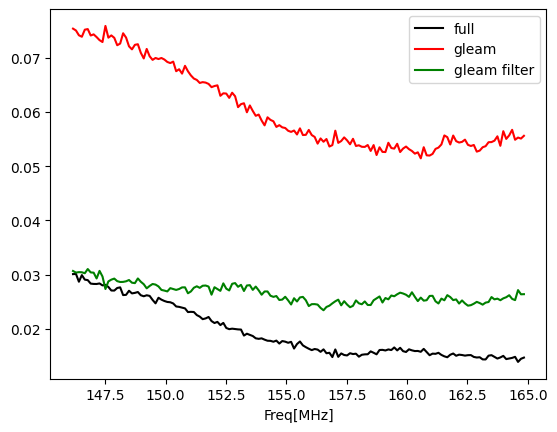

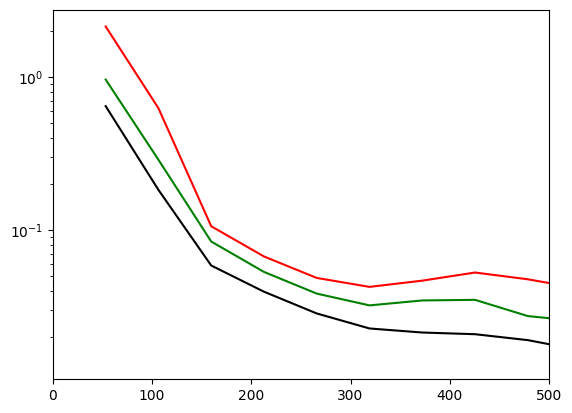

In [63]:
produce_plots_delay(n=0,N=100)

In [77]:
gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[90:100,50:-1])
gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[90:100,50:-1])
gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam_filter[90:100,50:-1])
gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full_filter[90:100,50:-1])


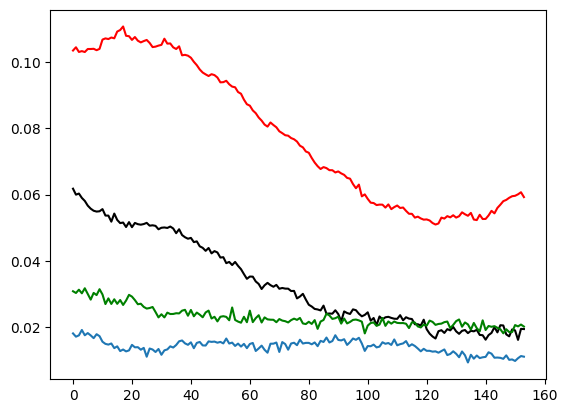

In [78]:
plt.plot(gains_full_ave,'k')
plt.plot(gains_gleam_ave, 'r')
plt.plot(gains_gleam_filter_ave, 'g')
plt.plot(gains_full_filter_ave)

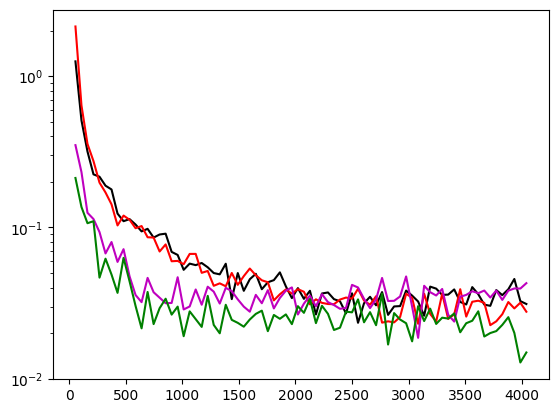

In [79]:
plt.semilogy(tau_pos, full_delay,'k')
plt.semilogy(tau_pos, gleam_delay,'r')
plt.semilogy(tau_pos, gleam_filter_delay,'m')
plt.semilogy(tau_pos, full_filter_delay,'g')
# plt.xlim([0,5000])

## Chis-sqaure

In [61]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

In [62]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_Notch_filter_40_mHz_redcal_"+uvh5name[i]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

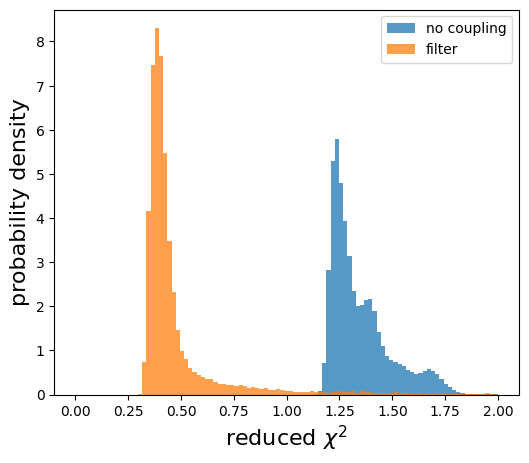

In [63]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="no coupling")
plt.hist(np.abs(chis_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()

In [9]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [12]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [13]:
pol=hd.polarization_array

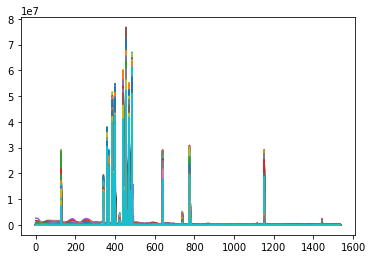

In [14]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [21]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [22]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



divide by zero encountered in log
divide by zero encountered in log
invalid value encountered in exp


In [23]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




invalid value encountered in true_divide
invalid value encountered in greater
invalid value encountered in greater


In [24]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

AttributeError: 'dict' object has no attribute 'gains'

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [27]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


KeyError: "Unable to open object (object 'phase_type' doesn't exist)"

In [69]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

Selected 134 data baselines and 134 model baselines to load.


In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [28]:
hc.abscal.post_redcal_abscal??

Signature:
hc.abscal.post_redcal_abscal(
    model,
    data,
    data_wgts,
    rc_flags,
    edge_cut=0,
    tol=1.0,
    kernel=(1, 15),
    phs_max_iter=100,
    phs_conv_crit=1e-06,
    verbose=True,
)
Source:   
def post_redcal_abscal(model, data, data_wgts, rc_flags, edge_cut=0, tol=1.0, kernel=(1, 15),
                       phs_max_iter=100, phs_conv_crit=1e-6, verbose=True):
    '''Performs Abscal for data that has already been redundantly calibrated.

    Arguments:
        model: DataContainer containing externally calibrated visibilities, LST-matched to the data.
            The model keys must match the data keys.
        data: DataContainer containing redundantly but not absolutely calibrated visibilities. This gets modified.
        data_wgts: DataContainer containing same keys as data, determines their relative weight in the abscal
            linear equation solvers.
        rc_flags: dictionary mapping keys like (1, 'Jnn') to flag waterfalls from redundant calibratio